In [1]:
# packages
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.model_selection import train_test_split 
from sklearn.tree import \
      (DecisionTreeRegressor as DTR, 
       DecisionTreeClassifier as DTC, 
       plot_tree)
from sklearn.ensemble import \
     (RandomForestRegressor as RFR,
      RandomForestClassifier as RFC,
      GradientBoostingRegressor as GBR)
from sklearn.model_selection import cross_val_score

# set seed
seed = 5498

### Load data

In [3]:
heart = pd.read_csv('data/heart.csv')
heart.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,UEX5427,40,Male,122,144/90,110,1,0,1,1,...,1.538008,252889,28.854477,318,6,7,Thailand,Asia,Northern Hemisphere,1
1,NBG3103,41,Male,357,174/73,109,0,1,1,1,...,7.030873,63196,37.387161,72,7,9,France,Europe,Northern Hemisphere,1
2,EIE1041,58,Male,206,107/105,63,0,0,1,0,...,8.086554,107870,20.299119,119,2,5,Colombia,South America,Northern Hemisphere,0
3,GYA0389,30,Male,142,132/107,86,1,0,1,0,...,5.039048,223985,30.717640,301,5,9,South Africa,Africa,Southern Hemisphere,0
4,IXT9616,69,Male,175,153/93,98,1,1,1,1,...,4.354972,24309,19.115698,675,7,7,Japan,Asia,Northern Hemisphere,0


In [4]:
heart.dtypes

Patient ID                          object
Age                                  int64
Sex                                 object
Cholesterol                          int64
Blood Pressure                      object
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                object
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                               int64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Country                             object
Continent  

In [5]:
heart.shape

(6572, 26)

### Feature engineering

In [6]:
def feature_engineering(df=heart):
    df['Male'] = (df.Sex == 'Male').astype(int)
    df['HealthyDiet'] = (df.Diet == 'Healthy').astype(int)
    df['UnhealthyDiet'] = (df.Diet == 'Unhealthy').astype(int)
    df[['BP1','BP2']] = df['Blood Pressure'].str.split('/', n=1, expand=True).astype(int)

feature_engineering()

In [7]:
heart.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Male,HealthyDiet,UnhealthyDiet,BP1,BP2
0,UEX5427,40,Male,122,144/90,110,1,0,1,1,...,7,Thailand,Asia,Northern Hemisphere,1,1,0,0,144,90
1,NBG3103,41,Male,357,174/73,109,0,1,1,1,...,9,France,Europe,Northern Hemisphere,1,1,1,0,174,73
2,EIE1041,58,Male,206,107/105,63,0,0,1,0,...,5,Colombia,South America,Northern Hemisphere,0,1,0,0,107,105
3,GYA0389,30,Male,142,132/107,86,1,0,1,0,...,9,South Africa,Africa,Southern Hemisphere,0,1,0,1,132,107
4,IXT9616,69,Male,175,153/93,98,1,1,1,1,...,7,Japan,Asia,Northern Hemisphere,0,1,0,1,153,93


In [8]:
indep_vars = ['Age', 'Male', 'Cholesterol', 'BP1', 'BP2', 'Heart Rate', 'Diabetes', 
              'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'HealthyDiet', 
              'UnhealthyDiet', 'Exercise Hours Per Week', 'Previous Heart Problems', 
              'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI',
              'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day']

X = heart[indep_vars]
y = heart['Heart Attack Risk']

In [9]:
X_train, X_test, y_train, y_test, Train, Test = train_test_split(X, y, heart, 
                                                                 random_state = seed, 
                                                                 test_size = 0.33, 
                                                                 shuffle = True)

### Univariate Analyses (Mean, Median, etc.)

In [10]:
Train.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Male,HealthyDiet,UnhealthyDiet,BP1,BP2
count,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,...,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000
mean,53.760164,261.571201,75.398592,0.656371,0.487168,0.895526,0.503066,0.599364,10.123129,0.506246,...,28.876482,418.384738,3.470815,7.045651,0.363389,0.703157,0.336589,0.334999,135.339768,85.200318
std,21.302684,81.111506,20.455754,0.474973,0.499892,0.305909,0.500047,0.490083,5.814093,0.500018,...,6.266748,222.756253,2.289825,1.986313,0.481030,0.456919,0.472597,0.472044,26.471761,14.656039
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004443,0.000000,...,18.009025,30.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,90.000000,60.000000
25%,35.000000,194.000000,58.000000,0.000000,0.000000,1.000000,0.000000,0.000000,5.081525,0.000000,...,23.397345,229.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,112.500000,72.000000
50%,54.000000,261.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.266242,1.000000,...,28.768101,419.000000,3.000000,7.000000,0.000000,1.000000,0.000000,0.000000,135.000000,85.000000
75%,72.000000,333.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.292125,1.000000,...,34.269966,608.000000,5.000000,9.000000,1.000000,1.000000,1.000000,1.000000,159.000000,98.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,...,39.997211,800.000000,7.000000,10.000000,1.000000,1.000000,1.000000,1.000000,180.000000,110.000000


### Correlation Matrix

In [11]:
X_train.corr().style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)

,Age,Male,Cholesterol,BP1,BP2,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,HealthyDiet,UnhealthyDiet,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day
Age,1.000000,0.027272,-0.009153,0.008641,-0.002659,-0.003114,-0.017869,0.017139,0.398364,-0.008461,0.001217,-0.007662,0.010590,0.010047,-0.009670,0.006967,0.013658,0.024350,0.005220,-0.010506,0.014587,-0.009942,-0.016148
Male,0.027272,1.000000,0.016676,-0.006140,0.001995,-0.000366,0.000917,-0.000270,0.525688,0.000504,0.005447,0.006229,-0.004378,-0.009530,-0.011272,0.006828,-0.039140,-0.010779,0.007646,0.010282,0.015317,0.003985,-0.007092
Cholesterol,-0.009153,0.016676,1.000000,0.005745,-0.017203,-0.012507,-0.028839,-0.032771,0.026621,-0.015891,-0.022353,0.004833,-0.014249,0.016741,-0.022367,-0.001884,-0.034351,0.027106,-0.001468,0.012924,-0.014398,0.029993,-0.002332
BP1,0.008641,-0.006140,0.005745,1.000000,0.010701,0.022688,-0.012339,-0.015910,0.001102,0.000024,0.000444,-0.010324,-0.003148,0.003553,-0.022952,-0.000809,0.016166,0.016528,-0.002618,0.020022,0.014007,-0.017409,0.008220
BP2,-0.002659,0.001995,-0.017203,0.010701,1.000000,-0.011255,-0.007699,0.041776,-0.031407,-0.010003,-0.010521,0.014009,-0.005860,-0.014261,-0.003488,0.004126,0.002516,-0.007814,0.022487,0.007131,0.008308,0.001704,0.013755
Heart Rate,-0.003114,-0.000366,-0.012507,0.022688,-0.011255,1.000000,0.013984,-0.021304,-0.010406,0.017814,-0.000881,-0.017735,-0.020490,-0.003555,-0.023864,0.003857,-0.004242,-0.037228,0.017454,-0.017648,-0.003075,0.016770,0.016767
Diabetes,-0.017869,0.000917,-0.028839,-0.012339,-0.007699,0.013984,1.000000,-0.017140,-0.006363,0.021175,0.012529,0.014430,-0.026492,-0.006420,0.006648,0.013017,0.001319,0.004841,0.009121,-0.015689,0.006697,0.013022,0.004351
Family History,0.017139,-0.000270,-0.032771,-0.015910,0.041776,-0.021304,-0.017140,1.000000,0.000144,-0.002796,0.000338,-0.001907,0.015815,-0.021142,-0.003542,-0.010742,0.015665,0.009992,0.008011,-0.023486,-0.016172,0.009348,-0.016454
Smoking,0.398364,0.525688,0.026621,0.001102,-0.031407,-0.010406,-0.006363,0.000144,1.000000,0.009520,0.016225,-0.000266,-0.007709,-0.006519,-0.018010,-0.002338,-0.022788,0.014017,0.007357,0.011295,0.033460,0.000835,-0.023927
Obesity,-0.008461,0.000504,-0.015891,0.000024,-0.010003,0.017814,0.021175,-0.002796,0.009520,1.000000,-0.035773,0.000438,-0.010608,0.012616,0.032404,-0.004300,-0.005804,0.000109,-0.003053,-0.011320,0.015713,0.016892,0.001803


### To predict heart attack risk, we'll start by building a few simple decision trees.

In [12]:
tree1 = DTC(max_depth=1)
tree1.fit(X_train, y_train)

tree2 = DTC(max_depth=2)
tree2.fit(X_train, y_train)

tree3 = DTC(max_depth=3)
tree3.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### We can draw plots of each of these decision trees

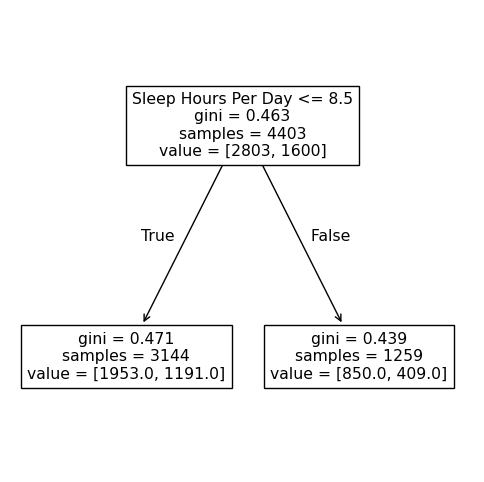

In [13]:
feature_names = list(X_train.columns)
ax = subplots(figsize=(6,6))[1]
plot_tree(tree1,
          feature_names=feature_names,
          ax=ax);

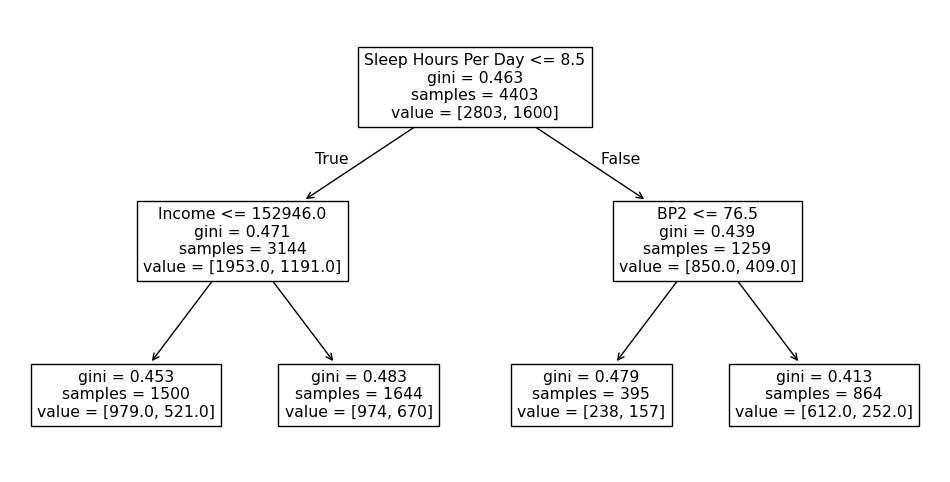

In [14]:
ax = subplots(figsize=(12,6))[1]
plot_tree(tree2,
          feature_names=feature_names,
          ax=ax);

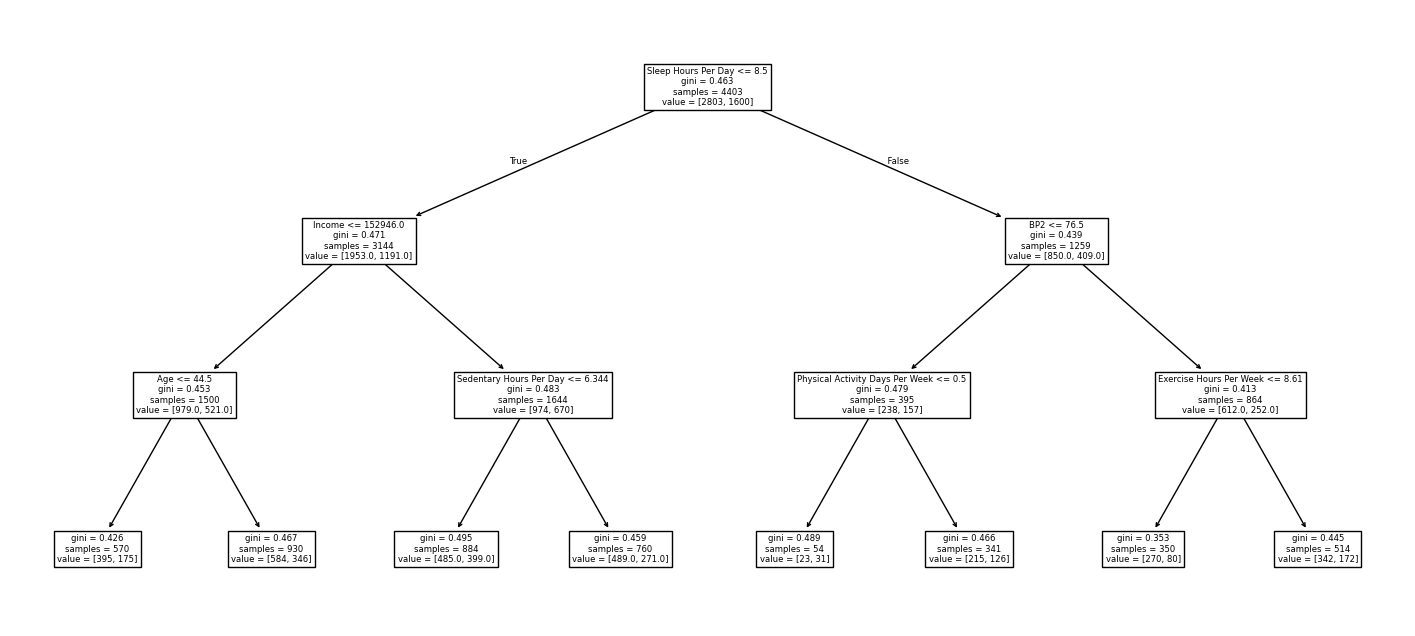

In [15]:
ax = subplots(figsize=(18,8))[1]
plot_tree(tree3,
          feature_names=feature_names,
          ax=ax);

### Create a new tree with depth 3 that requires there to be at least 100 records in each leaf.

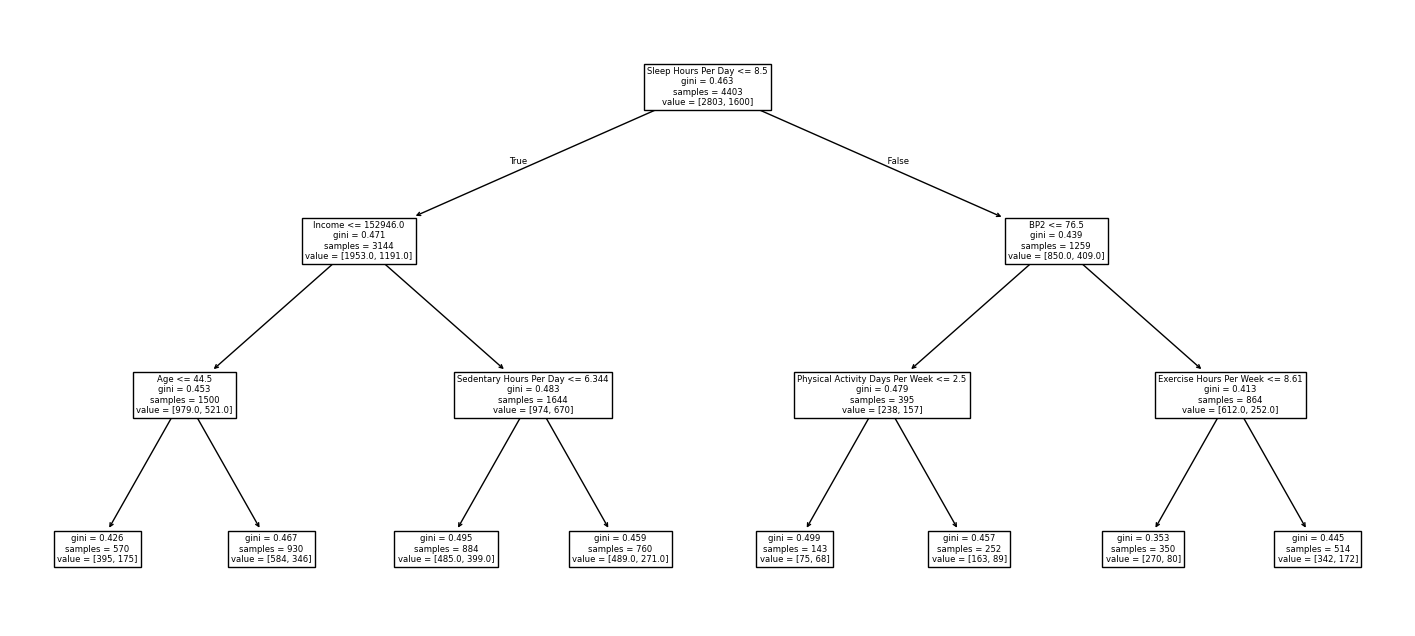

In [45]:
tree4 = DTC(max_depth=3, min_samples_leaf=100)
tree4.fit(X_train, y_train)

ax = subplots(figsize=(18,8))[1]
plot_tree(tree4,
          feature_names=feature_names,
          ax=ax);

### Create a new version of the last tree so that it limits the number of leaf nodes to 8 rather than limiting the depth to 3.

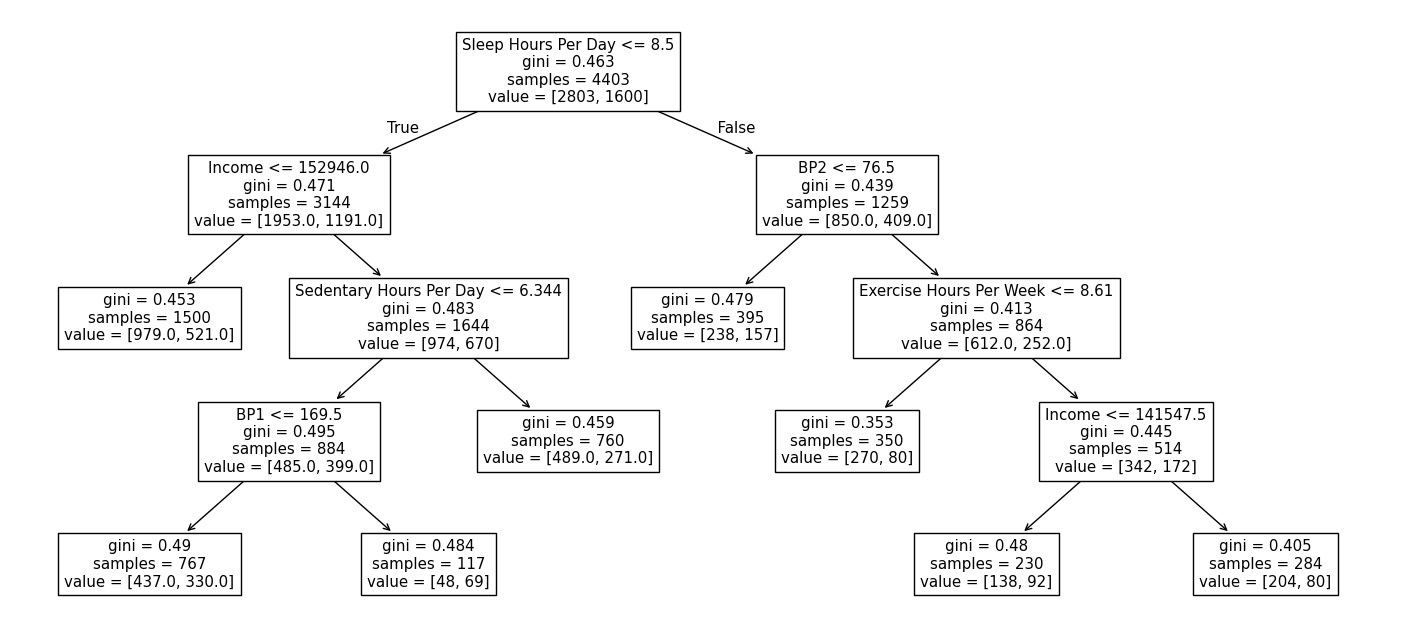

In [46]:
tree5 = DTC(max_leaf_nodes=8, min_samples_leaf=100)
tree5.fit(X_train, y_train)
ax = subplots(figsize=(18,8))[1]
plot_tree(tree5,
          feature_names=feature_names,
          ax=ax);

### Create a basic random forest model on the training set.

In [18]:
rf_basic = RFC(max_features=len(indep_vars),
               criterion='log_loss',
               n_estimators=50,
               max_depth=10,
               min_samples_leaf=1,
               bootstrap=True,
               oob_score=True,
               random_state=seed)
rf_basic.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'log_loss'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",23
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

### We'll use this function to quickly calculate the log loss of a model.

In [19]:
def log_loss(y_true, y_prob, eps=1e-15):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    # avoid log(0)
    y_prob = np.clip(y_prob, eps, 1 - eps)
    
    ll = -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    return ll

### Compute the log loss on the training set.

In [20]:
y_hat_basic_train = rf_basic.predict_proba(X_train)[:,1]
print('train log loss:', log_loss(y_train, y_hat_basic_train))

train log loss: 0.4682493561945568


### Calculate the out-of-bag error (bootstrapping) on training data to estimate the log loss on the test set.

In [42]:
y_hat_basic_oob = rf_basic.oob_decision_function_[:,1]
print('oob log loss:  ', log_loss(y_train, y_hat_basic_oob))

oob log loss:   0.6662770624624337


### Compute the log loss on the test set.

In [22]:
y_hat_basic_test = rf_basic.predict_proba(X_test)[:,1]
print('test log loss: ', log_loss(y_test, y_hat_basic_test))

test log loss:  0.65752143530385


### Build an improved random forest model on this same set of data. 

You will be scored according to how well it performs on an unseen holdout set.

In [47]:
# Documentation: https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.RandomForestRegressor.html

rf_better = RFC(max_features=len(indep_vars),
               criterion='log_loss',
               n_estimators=200,
               max_depth=None,
               min_samples_leaf=2,
               bootstrap=True,
               oob_score=True,
               random_state=seed)
rf_better.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'log_loss'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",23
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Calculate the out-of-bag log loss for this model. Store it as `log_loss_oob`

In [48]:
y_hat_better_oob = rf_better.predict_proba(X_train)[:,1]

log_loss_oob = log_loss(y_train, y_hat_better_oob)
print(log_loss_oob)


0.22522438525775143


### Create the feature importance list for this model.

In [49]:
feature_imp = pd.DataFrame(
    {'importance':rf_better.feature_importances_},
    index=indep_vars)
feature_imp

,importance
Age,0.071952
Male,0.008438
Cholesterol,0.080122
BP1,0.073182
BP2,0.069618
Heart Rate,0.070066
Diabetes,0.008931
Family History,0.009113
Smoking,0.003418
Obesity,0.009114


### Sort the importance values and then create a horizontal bar chart that displays the sorted variable importances.

<Axes: >

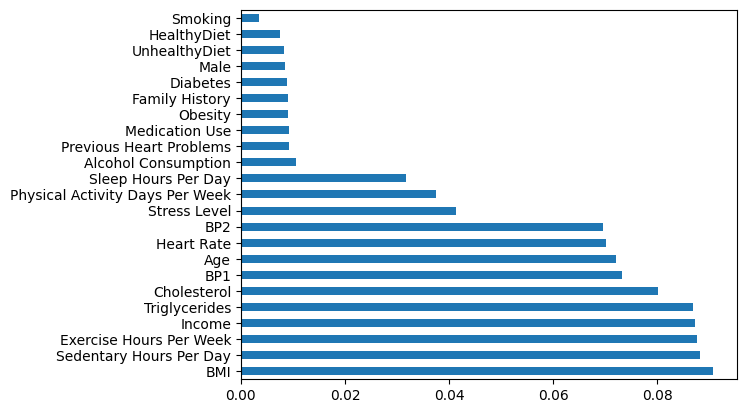

In [50]:
feature_imp_sorted = feature_imp.sort_values(by="importance", ascending=False)

# Draw a horizontal bar chart
#fillin
feature_imp_sorted.plot.barh(legend=False)

## Discussion Questions

### (1) Explain what "value" means in the decision tree plots.

How the samples are divided by class. The classes are "has heart disease" and "does not have heart disease".

### (2) How is “log loss” different from the log likelihood we defined in class?

It's based on loss per individual samples and its negated because the goal is to minimize loss unlike log likelihood.

### (3) Explain how we know the basic model is overfit before attempting to build any other models.

Because the log loss that was found for training was much lower than oob and test